In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/DSS5104/results'

expected_files = [
    'baseline_results.csv',
    'tabnet_results.csv',
    'ftt_results.csv',
]

print("📁 检查文件...")
all_ok = True
for f in expected_files:
    path = os.path.join(SAVE_DIR, f)
    if os.path.exists(path):
        print(f"  ✅ {f}")
    else:
        print(f"  ❌ {f} 不存在！")
        all_ok = False

if all_ok:
    print("\n✅ 所有文件齐全，可以开始分析！")
else:
    print("\n⚠️ 有文件缺失，请先上传到 Google Drive")

Mounted at /content/drive
📁 检查文件...
  ✅ baseline_results.csv
  ✅ tabnet_results.csv
  ✅ ftt_results.csv

✅ 所有文件齐全，可以开始分析！


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')

SAVE_DIR = '/content/drive/MyDrive/DSS5104/results'
FIG_DIR  = '/content/drive/MyDrive/DSS5104/figures'
os.makedirs(FIG_DIR, exist_ok=True)

print("✅ Ready")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Ready


In [3]:
df_baseline = pd.read_csv(f'{SAVE_DIR}/baseline_results.csv')
df_tabnet   = pd.read_csv(f'{SAVE_DIR}/tabnet_results.csv')
df_ftt      = pd.read_csv(f'{SAVE_DIR}/ftt_results.csv')

df_all = pd.concat([df_baseline, df_tabnet, df_ftt], ignore_index=True)

print("✅ All results loaded")
print(f"Total rows: {len(df_all)}")
print(df_all['model'].unique())

✅ All results loaded
Total rows: 36
['XGBoost' 'Linear' 'TabNet' 'FT-Transformer']


In [4]:
# 分数值和误差
df_all[['mean', 'std']] = df_all['value'].str.split(' ± ', expand=True).astype(float)

# 分数据集生成表格
for ds in ['california', 'adult', 'covertype']:
    print(f"\n{'='*60}")
    print(f"📊 {ds.upper()}")
    print('='*60)
    pivot = df_all[df_all['dataset']==ds].pivot_table(
        index='metric', columns='model', values='mean', aggfunc='first')
    # 固定列顺序
    col_order = [c for c in ['Linear','XGBoost','TabNet','FT-Transformer'] if c in pivot.columns]
    pivot = pivot[col_order]
    print(pivot.round(4).to_string())


📊 CALIFORNIA
model   Linear  XGBoost  TabNet  FT-Transformer
metric                                         
MAE     0.5341   0.3006  0.4379          0.3038
R2      0.5978   0.8460  0.6779          0.8249
RMSE    0.7426   0.4595  0.6645          0.4899

📊 ADULT
model     Linear  XGBoost  TabNet  FT-Transformer
metric                                           
AUC       0.8497   0.9281  0.9042          0.8927
Accuracy  0.8250   0.8757  0.8536          0.8438
F1        0.5467   0.7156  0.6553          0.6573

📊 COVERTYPE
model     Linear  XGBoost  TabNet  FT-Transformer
metric                                           
AUC       0.9329   0.9819  0.9623          0.9723
Accuracy  0.7156   0.8481  0.8191          0.8591
F1        0.5071   0.8150  0.7014          0.7822


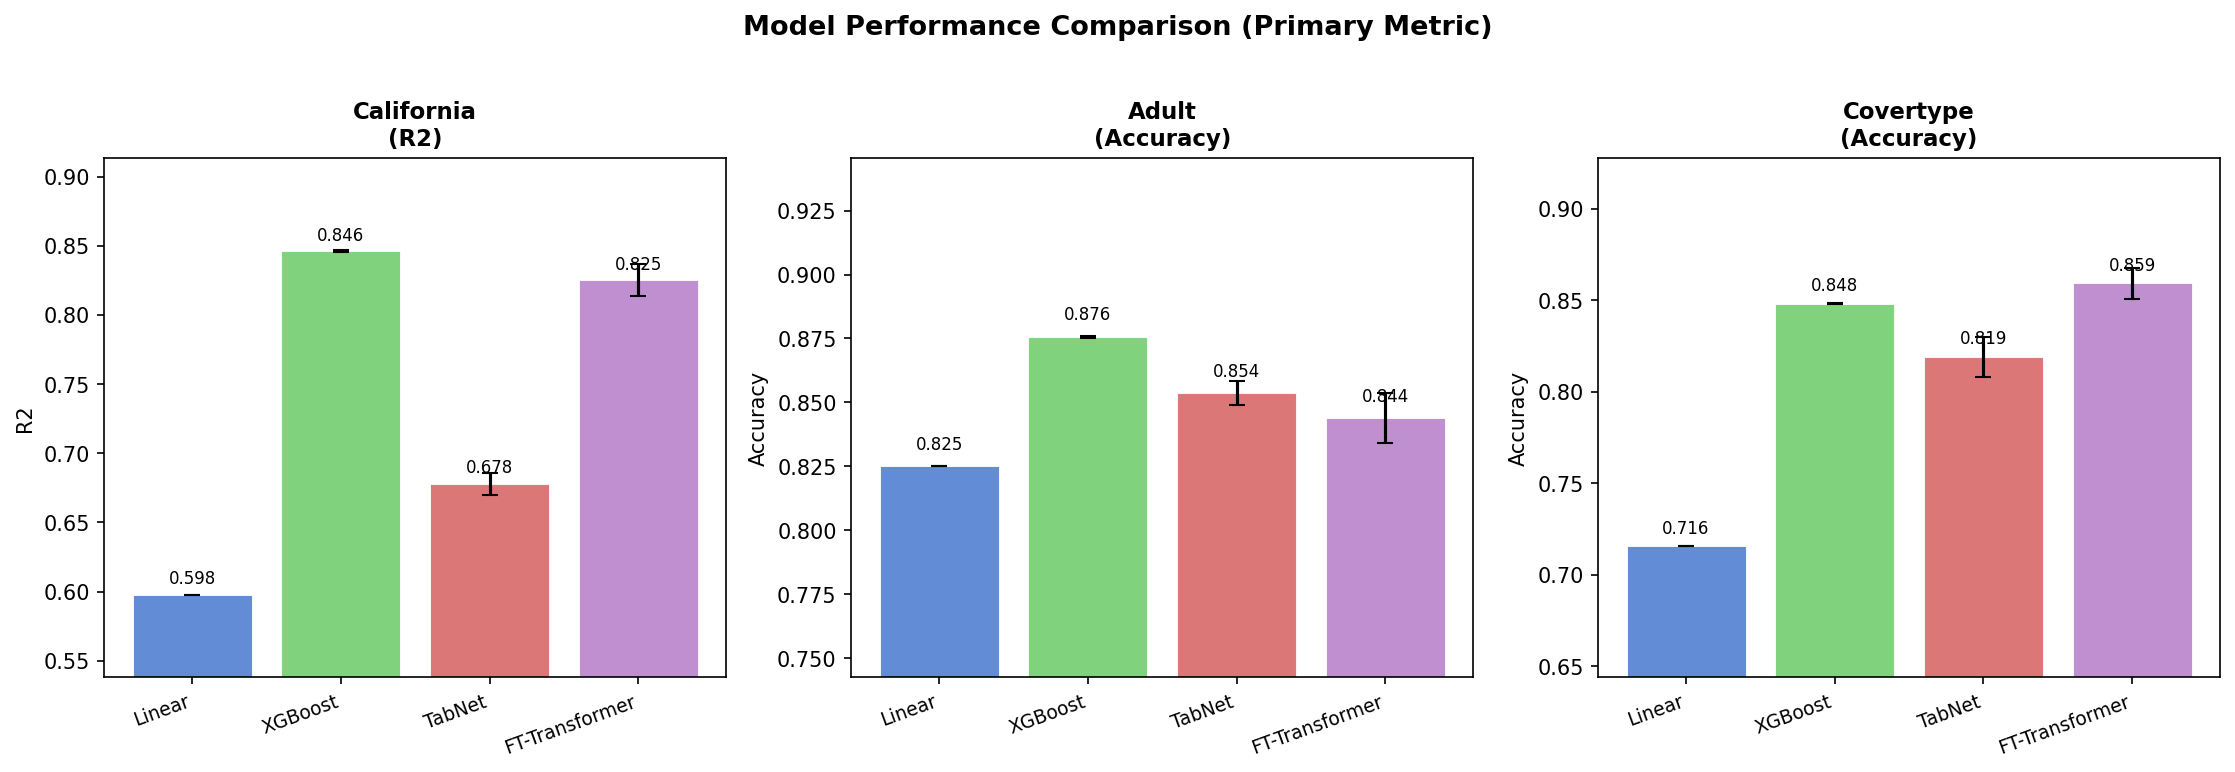

✅ Figure 1 saved


In [5]:
datasets_list = ['california', 'adult', 'covertype']
primary_metric = {'california': 'R2', 'adult': 'Accuracy', 'covertype': 'Accuracy'}
models = ['Linear', 'XGBoost', 'TabNet', 'FT-Transformer']
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ds in zip(axes, datasets_list):
    metric = primary_metric[ds]
    vals, errs = [], []
    for model in models:
        row = df_all[(df_all['dataset']==ds) &
                     (df_all['model']==model) &
                     (df_all['metric']==metric)]
        if len(row) > 0:
            vals.append(row['mean'].values[0])
            errs.append(row['std'].values[0])
        else:
            vals.append(0)
            errs.append(0)

    x = np.arange(len(models))
    bars = ax.bar(x, vals, yerr=errs, capsize=4,
                  color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.set_title(f'{ds.capitalize()}\n({metric})', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(min(vals)*0.9, min(max(vals)*1.08, 1.0) if metric in ['Accuracy','AUC','F1'] else max(vals)*1.08)

    # 在柱子上标数值
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison (Primary Metric)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_performance_comparison.png', bbox_inches='tight')
plt.show()
print("✅ Figure 1 saved")

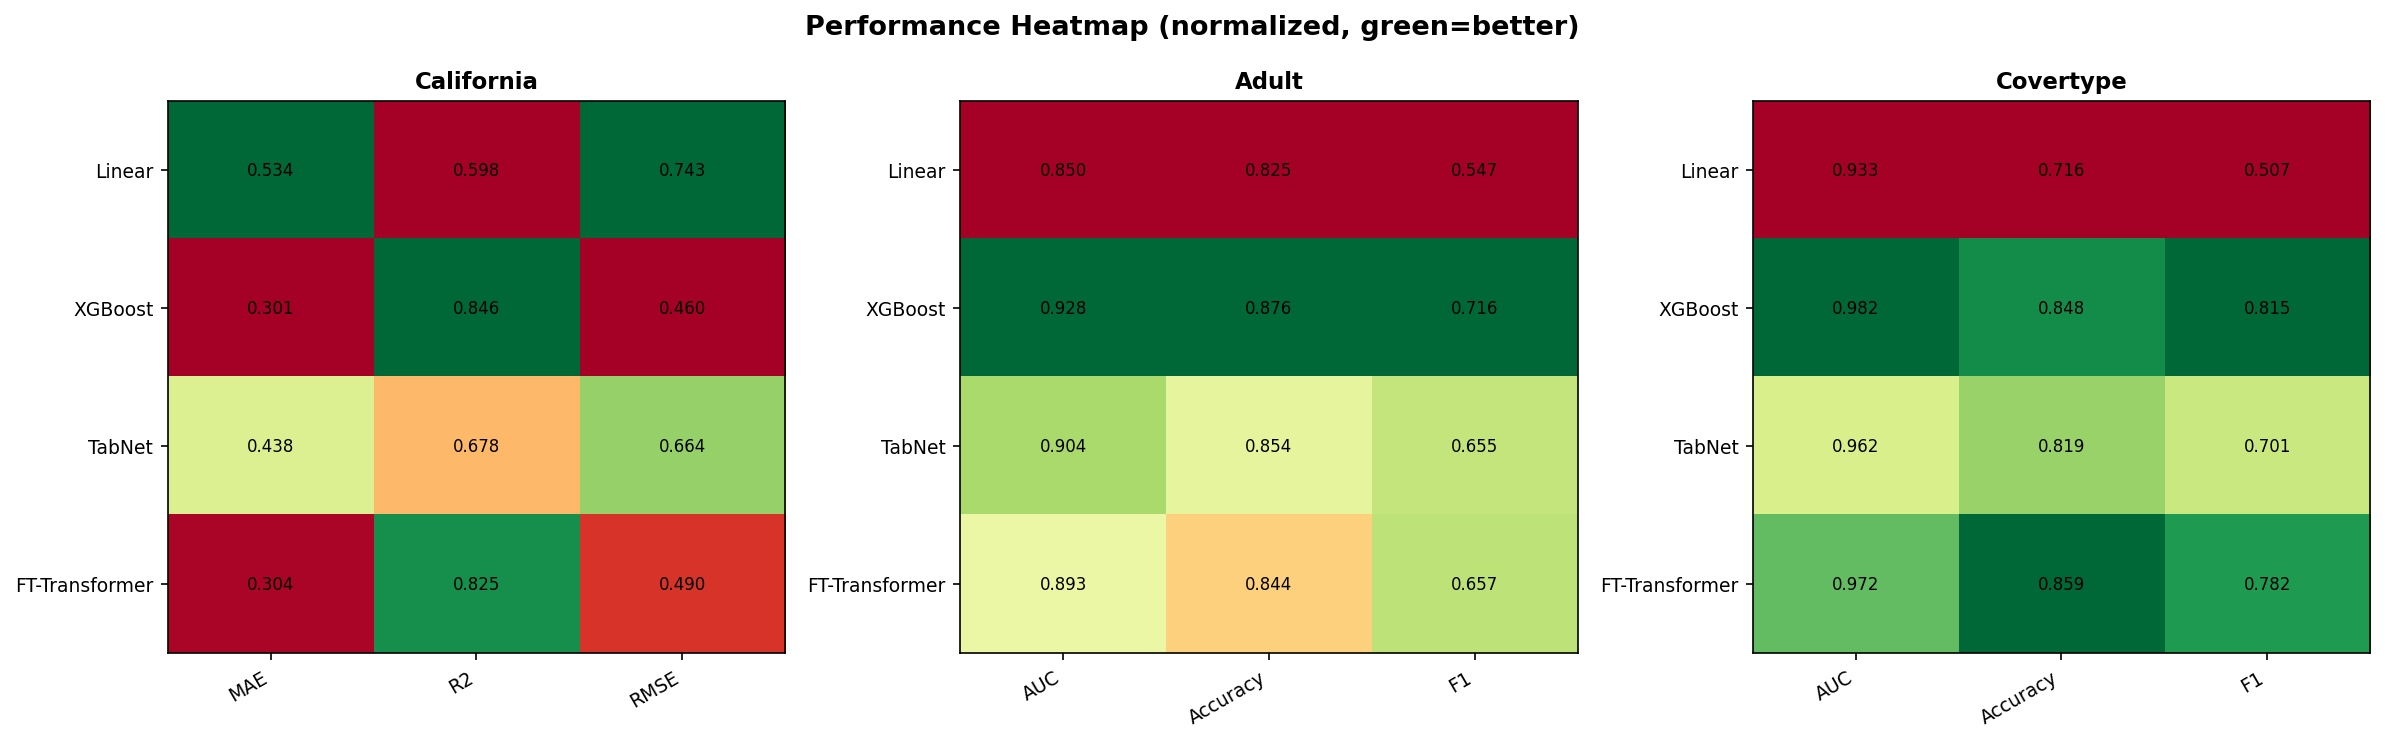

✅ Figure 2 saved


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ds in zip(axes, datasets_list):
    ds_data = df_all[df_all['dataset']==ds].copy()
    pivot = ds_data.pivot_table(index='model', columns='metric',
                                values='mean', aggfunc='first')
    pivot = pivot.reindex([m for m in models if m in pivot.index])

    # 归一化到 0-1（方便热力图对比）
    pivot_norm = (pivot - pivot.min()) / (pivot.max() - pivot.min() + 1e-8)

    im = ax.imshow(pivot_norm.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(f'{ds.capitalize()}', fontsize=11, fontweight='bold')

    # 在格子里标原始数值
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=8, color='black')

plt.suptitle('Performance Heatmap (normalized, green=better)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Figure 2 saved")

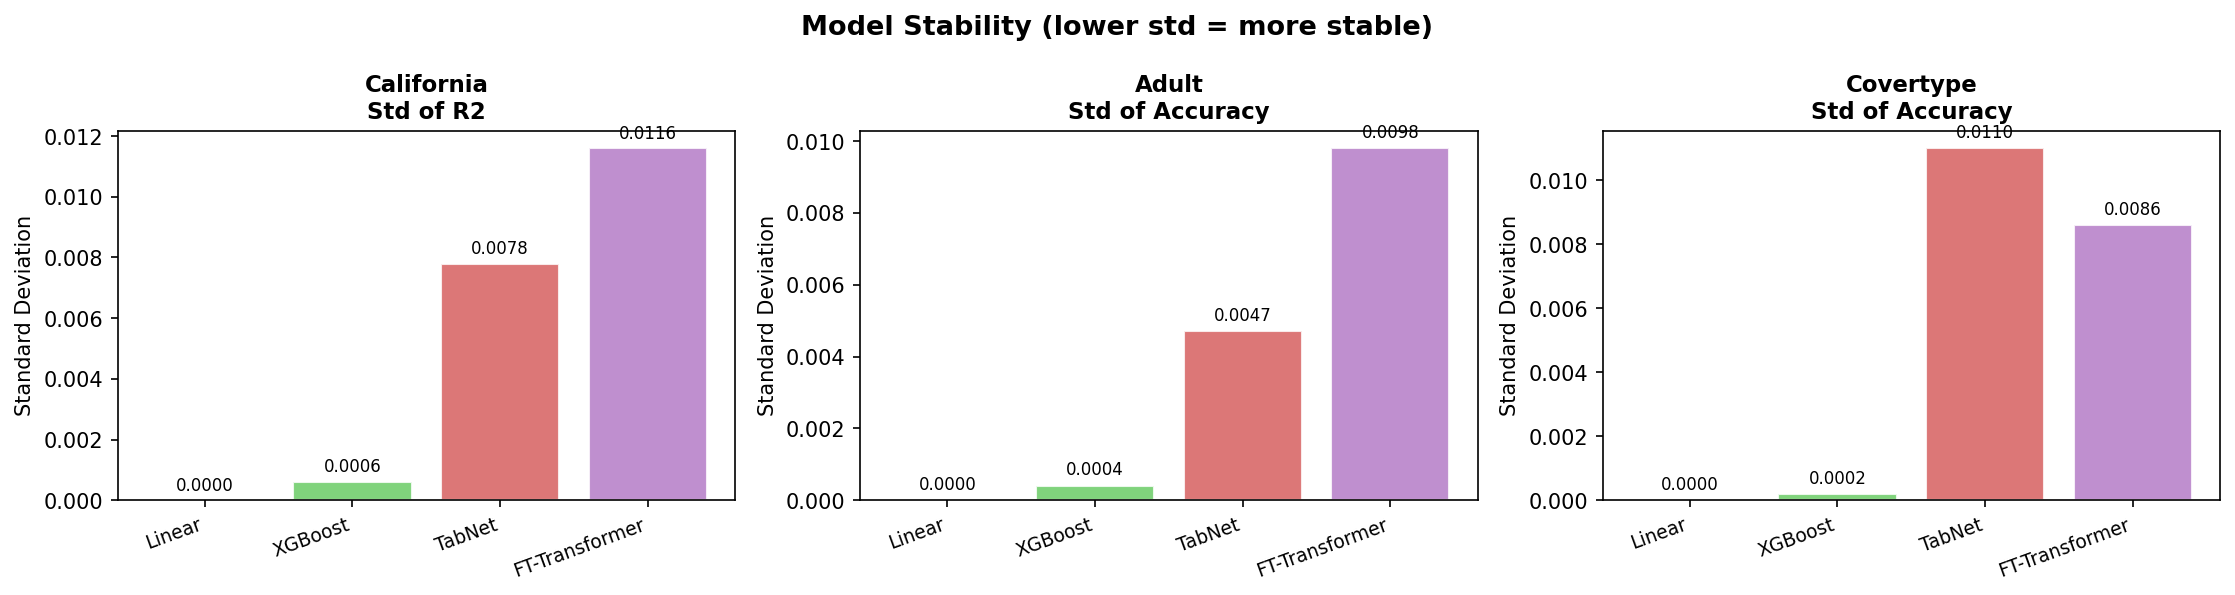

✅ Figure 3 saved


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ds in zip(axes, datasets_list):
    metric = primary_metric[ds]
    stds = []
    valid_models = []
    for model in models:
        row = df_all[(df_all['dataset']==ds) &
                     (df_all['model']==model) &
                     (df_all['metric']==metric)]
        if len(row) > 0:
            stds.append(row['std'].values[0])
            valid_models.append(model)

    x = np.arange(len(valid_models))
    ax.bar(x, stds, color=colors[:len(valid_models)], alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(valid_models, rotation=20, ha='right', fontsize=9)
    ax.set_title(f'{ds.capitalize()}\nStd of {metric}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Standard Deviation')

    for i, (xi, std) in enumerate(zip(x, stds)):
        ax.text(xi, std + 0.0002, f'{std:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Stability (lower std = more stable)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_stability.png', bbox_inches='tight')
plt.show()
print("✅ Figure 3 saved")

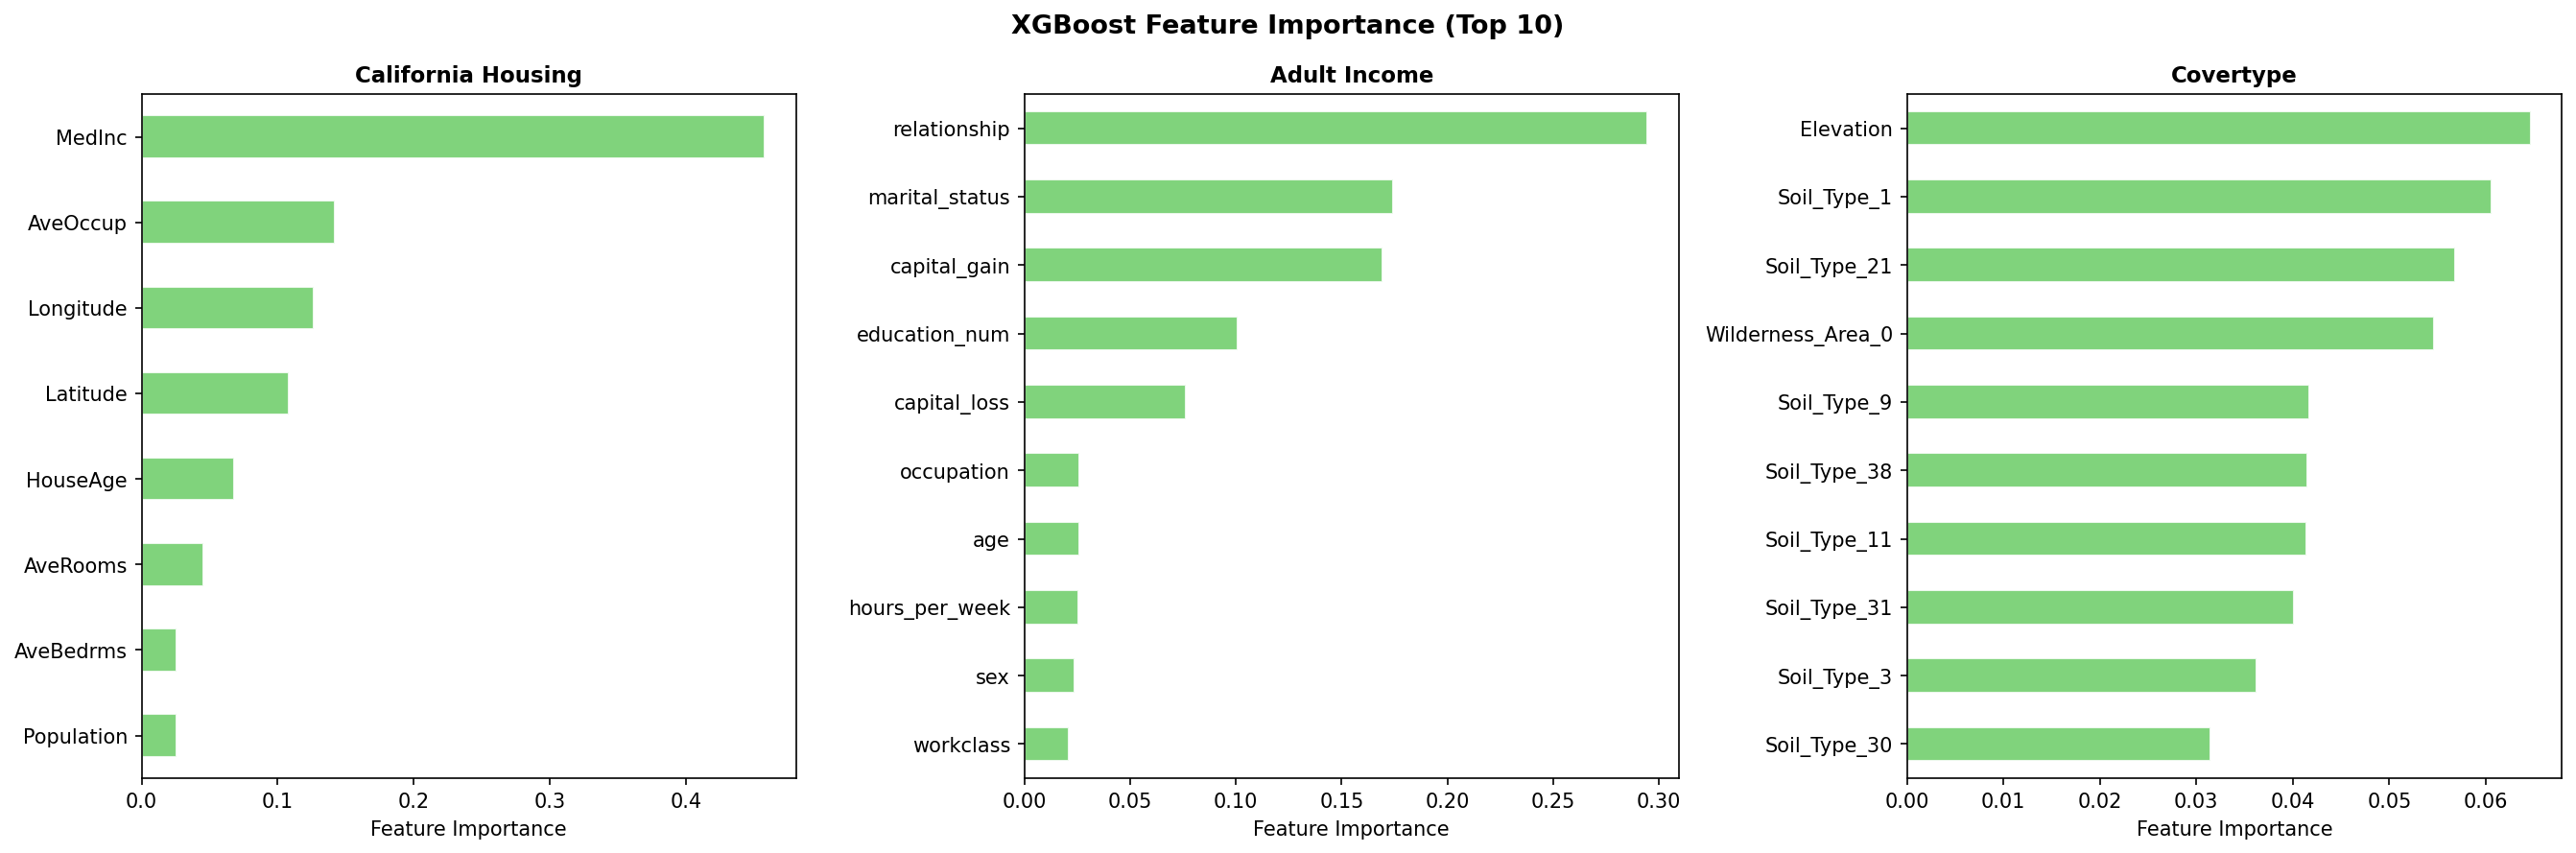

✅ Figure 4 saved


In [8]:
import pickle
from sklearn.datasets import fetch_california_housing, fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import xgboost as xgb

def get_xgb_importance(df, target_col, task, title, ax, top_n=10):
    df = df.copy()
    X = df.drop(columns=[target_col])
    y = df[target_col].values

    cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
    num_cols = X.select_dtypes(include=['number']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].fillna('__missing__')
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    for col in num_cols:
        X[col] = X[col].fillna(X[col].median())

    feature_names = num_cols + cat_cols
    X = X[feature_names].values.astype(float)

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    if task == 'regression':
        model = xgb.XGBRegressor(n_estimators=300, random_state=42,
                                  objective='reg:squarederror')
    else:
        n_cls = len(np.unique(y))
        model = xgb.XGBClassifier(
            n_estimators=300, random_state=42,
            objective='multi:softprob' if n_cls>2 else 'binary:logistic',
            num_class=n_cls if n_cls>2 else None,
            eval_metric='mlogloss' if n_cls>2 else 'logloss')
    model.fit(X_tr, y_tr, verbose=False)

    importance = pd.Series(model.feature_importances_, index=feature_names)
    top = importance.nlargest(top_n).sort_values()

    top.plot(kind='barh', ax=ax, color='#6ACC65', alpha=0.85, edgecolor='white')
    ax.set_title(f'{title}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature Importance')

# 加载数据
raw = fetch_california_housing(as_frame=True)
df_cal = raw.frame.copy()

col_names = ['age','workclass','fnlwgt','education','education_num',
             'marital_status','occupation','relationship','race','sex',
             'capital_gain','capital_loss','hours_per_week','native_country','income']
df_a1 = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
                    header=None, names=col_names, skipinitialspace=True, na_values='?')
df_a2 = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test",
                    header=None, names=col_names, skipinitialspace=True, na_values='?', skiprows=1)
df_adult = pd.concat([df_a1, df_a2], ignore_index=True)
df_adult['income'] = df_adult['income'].str.replace('.','',regex=False).str.strip()
df_adult['income'] = (df_adult['income'] == '>50K').astype(int)

raw_cov = fetch_covtype(as_frame=True)
df_cov = raw_cov.frame.copy()
df_cov = df_cov.sample(n=20_000, random_state=42).reset_index(drop=True)
df_cov['Cover_Type'] = df_cov['Cover_Type'] - 1

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

get_xgb_importance(df_cal,   'MedHouseVal', 'regression',      'California Housing', axes[0])
get_xgb_importance(df_adult, 'income',      'classification',  'Adult Income',       axes[1])
get_xgb_importance(df_cov,   'Cover_Type',  'multiclassification', 'Covertype',      axes[2])

plt.suptitle('XGBoost Feature Importance (Top 10)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_feature_importance.png', bbox_inches='tight')
plt.show()
print("✅ Figure 4 saved")

In [9]:
print("\n" + "="*70)
print("📊 COMPLETE RESULTS TABLE (for report)")
print("="*70)

for ds in ['california', 'adult', 'covertype']:
    print(f"\n── {ds.upper()} ──")
    sub = df_all[df_all['dataset']==ds].copy()
    sub['result'] = sub['mean'].round(4).astype(str) + ' ± ' + sub['std'].round(4).astype(str)
    pivot = sub.pivot_table(index='metric', columns='model',
                            values='result', aggfunc='first')
    col_order = [c for c in ['Linear','XGBoost','TabNet','FT-Transformer']
                 if c in pivot.columns]
    print(pivot[col_order].to_string())

print("\n✅ Analysis complete! All figures saved to Google Drive.")
print(f"📁 Figures location: {FIG_DIR}")


📊 COMPLETE RESULTS TABLE (for report)

── CALIFORNIA ──
model         Linear          XGBoost           TabNet   FT-Transformer
metric                                                                 
MAE     0.5341 ± 0.0  0.3006 ± 0.0011  0.4379 ± 0.0057  0.3038 ± 0.0082
R2      0.5978 ± 0.0   0.846 ± 0.0006  0.6779 ± 0.0078  0.8249 ± 0.0116
RMSE    0.7426 ± 0.0  0.4595 ± 0.0008  0.6645 ± 0.0081   0.4899 ± 0.016

── ADULT ──
model           Linear          XGBoost           TabNet   FT-Transformer
metric                                                                   
AUC       0.8497 ± 0.0  0.9281 ± 0.0003  0.9042 ± 0.0077  0.8927 ± 0.0091
Accuracy   0.825 ± 0.0  0.8757 ± 0.0004  0.8536 ± 0.0047  0.8438 ± 0.0098
F1        0.5467 ± 0.0  0.7156 ± 0.0009   0.6553 ± 0.005  0.6573 ± 0.0192

── COVERTYPE ──
model           Linear          XGBoost           TabNet   FT-Transformer
metric                                                                   
AUC       0.9329 ± 0.0     0.9819 ±